# SHAP Analysis — Home Credit Default Risk

**Goal:** Explain *why* the XGBoost model (CV AUC 0.757) predicts default, per feature and per applicant — not just *which* features matter (gain importance), but *how* each feature value pushes risk up or down.

**Method:** SHAP (SHapley Additive exPlanations) with `TreeExplainer` — exact Shapley values for tree ensembles. Every prediction is decomposed as:

$$\text{model output (log-odds)} = \text{base value} + \sum_i \phi_i$$

where $\phi_i$ is feature $i$'s contribution. Positive SHAP = pushes toward **default**, negative = pushes toward **repayment**.

Pipeline below replicates `EDA.ipynb` exactly (same cleaning, features, model params, random seed) so the explanations refer to the same 0.76-AUC model reported in the README.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

print('shap', shap.__version__, '| xgboost', xgboost.__version__)
shap.initjs()

shap 0.52.0 | xgboost 3.2.0


## 1. Rebuild the pipeline (identical to EDA.ipynb)

Cleaning → feature engineering → one-hot → 80/20 stratified split → XGBoost with `scale_pos_weight`.

In [2]:
df = pd.read_csv('/Users/j.a.r.v.i.s./Documents/Home Credit Default Risk/application_train.csv')

# Drop columns >40% null
null_pct = df.isnull().mean() * 100
df.drop(columns=null_pct[null_pct > 40].index.to_list(), inplace=True)

# DAYS_EMPLOYED sentinel -> NaN + anomaly flag
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Engineered features
df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365
df['BURDEN'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['CREDITxBURDEN'] = df['BURDEN'] * df['EXT_SOURCE_MEAN']
df['CREDITxAGE'] = df['AGE_YEARS'] * df['EXT_SOURCE_MEAN']
df['CREDITxINCOME'] = df['AMT_INCOME_TOTAL'] * df['EXT_SOURCE_MEAN']

# One-hot
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'train {X_train.shape}, test {X_test.shape}, default rate {y.mean():.4f}')

train (246008, 179), test (61503, 179), default rate 0.0807


In [3]:
weight = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(
    scale_pos_weight=weight,
    eval_metric='auc',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
)
model.fit(X_train, y_train)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f'Test AUC: {auc:.4f}  (README: 0.762)')

Test AUC: 0.7621  (README: 0.762)


## 2. Compute SHAP values

`TreeExplainer` on the full test set (61,503 applicants the model never trained on). Values are in **log-odds** — the model's raw margin, before the sigmoid squashes it into a probability.

In [4]:
explainer = shap.TreeExplainer(model)
sv = explainer(X_test)
print('SHAP matrix:', sv.values.shape)
print(f'base value (log-odds): {sv.base_values[0]:.4f}')

# Sanity check: base + sum(phi) must equal the raw margin
raw = model.predict(X_test.iloc[:5], output_margin=True)
recon = sv.base_values[:5] + sv.values[:5].sum(axis=1)
print('additivity check (max abs diff):', np.abs(raw - recon).max())

SHAP matrix: (61503, 179)
base value (log-odds): -0.0007
additivity check (max abs diff): 2.3841858e-07


## 3. Global importance — mean |SHAP|

Average absolute contribution per feature across all test applicants. Unlike gain importance, this is measured in the model's actual output units and is consistent (a feature that matters more never gets a smaller value).

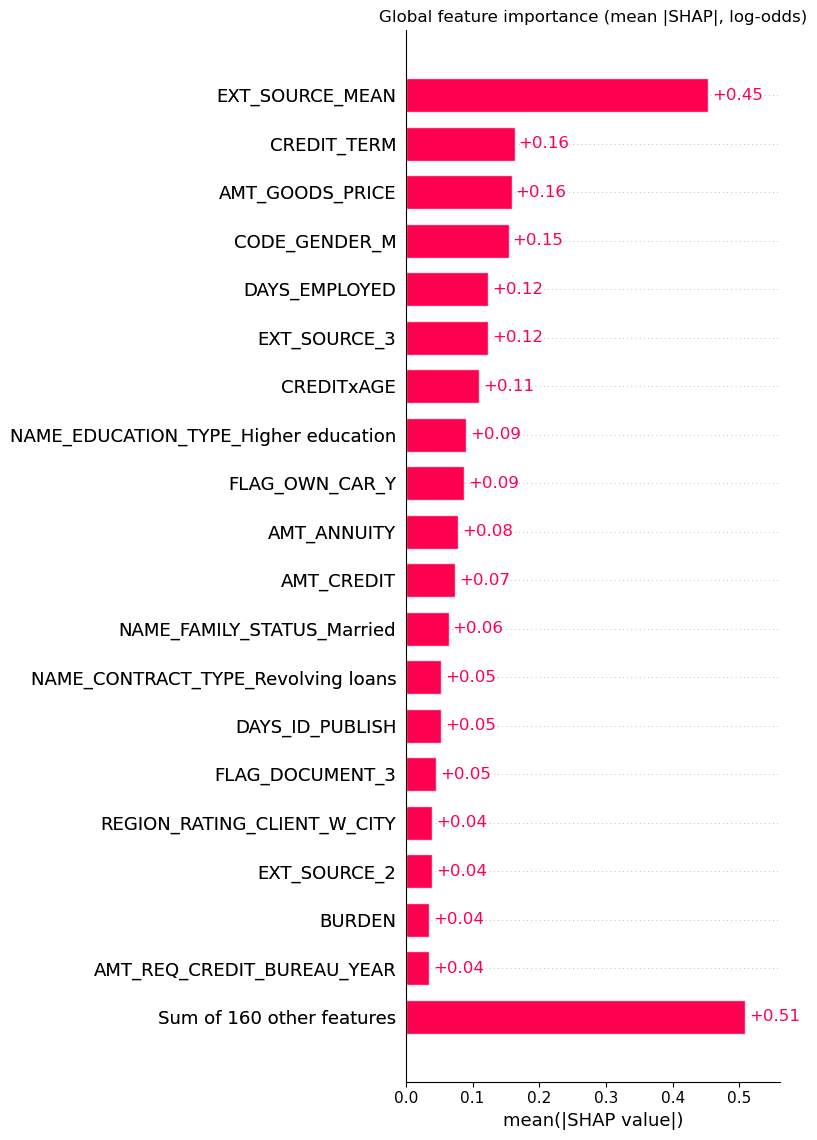

EXT_SOURCE_MEAN                         0.4527
CREDIT_TERM                             0.1630
AMT_GOODS_PRICE                         0.1583
CODE_GENDER_M                           0.1539
DAYS_EMPLOYED                           0.1237
EXT_SOURCE_3                            0.1226
CREDITxAGE                              0.1096
NAME_EDUCATION_TYPE_Higher education    0.0906
FLAG_OWN_CAR_Y                          0.0873
AMT_ANNUITY                             0.0781
AMT_CREDIT                              0.0732
NAME_FAMILY_STATUS_Married              0.0641
NAME_CONTRACT_TYPE_Revolving loans      0.0528
DAYS_ID_PUBLISH                         0.0525
FLAG_DOCUMENT_3                         0.0451
dtype: float32


In [5]:
shap.plots.bar(sv, max_display=20, show=False)
plt.title('Global feature importance (mean |SHAP|, log-odds)')
plt.tight_layout()
plt.show()

mean_abs = pd.Series(np.abs(sv.values).mean(axis=0), index=X_test.columns)
top15_shap = mean_abs.sort_values(ascending=False).head(15)
print(top15_shap.round(4))

### SHAP vs XGBoost gain importance

Do the two rankings agree? Gain measures training-loss reduction; SHAP measures actual impact on predictions.

In [6]:
gain = pd.Series(model.feature_importances_, index=X_train.columns)
cmp = pd.DataFrame({
    'mean_abs_SHAP': mean_abs,
    'SHAP_rank': mean_abs.rank(ascending=False).astype(int),
    'gain': gain,
    'gain_rank': gain.rank(ascending=False).astype(int),
}).sort_values('mean_abs_SHAP', ascending=False).head(15)
cmp.round(4)

,mean_abs_SHAP,SHAP_rank,gain,gain_rank
EXT_SOURCE_MEAN,0.4527,1,0.1579,1
CREDIT_TERM,0.1630,2,0.0155,11
AMT_GOODS_PRICE,0.1583,3,0.0119,18
CODE_GENDER_M,0.1539,4,0.0262,5
DAYS_EMPLOYED,0.1237,5,0.0155,12
EXT_SOURCE_3,0.1226,6,0.0145,13
CREDITxAGE,0.1096,7,0.0305,3
NAME_EDUCATION_TYPE_Higher education,0.0906,8,0.0396,2
FLAG_OWN_CAR_Y,0.0873,9,0.0171,10
AMT_ANNUITY,0.0781,10,0.0105,21


## 4. Beeswarm — direction and shape of each effect

Each dot = one applicant. Color = feature value (red high, blue low). Position = SHAP value (right = pushes toward default).

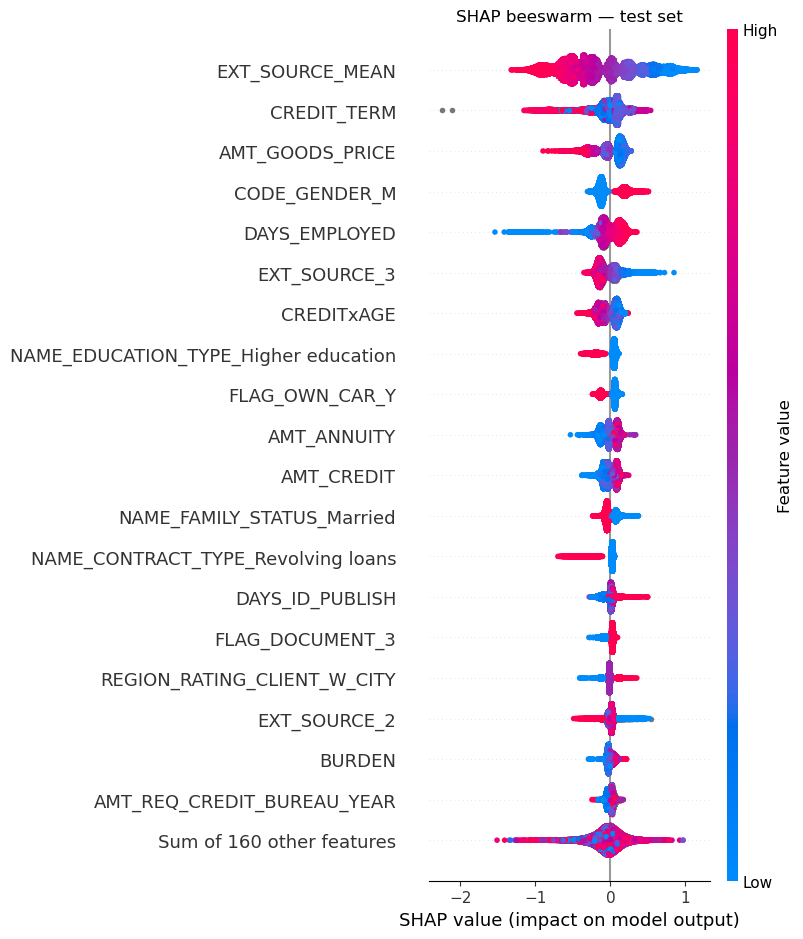

In [7]:
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title('SHAP beeswarm — test set')
plt.tight_layout()
plt.show()

## 5. Dependence plots — top individual features

SHAP value vs feature value, colored by the feature SHAP picks as the strongest interaction partner. Reveals the *shape* of each effect (linear, threshold, saturating) that a bar chart hides.

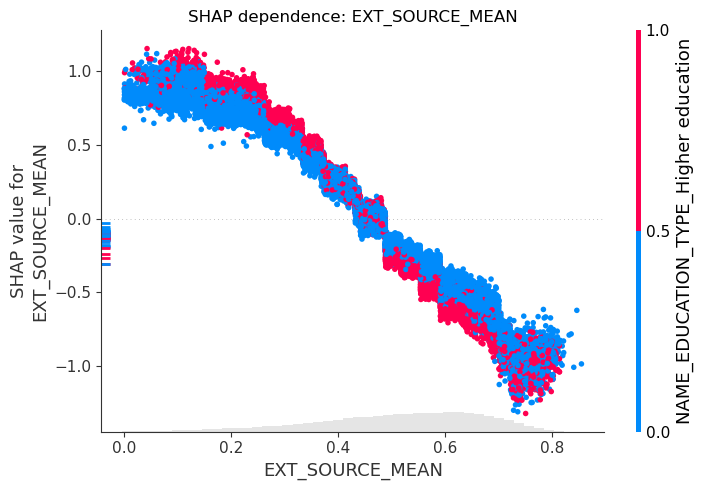

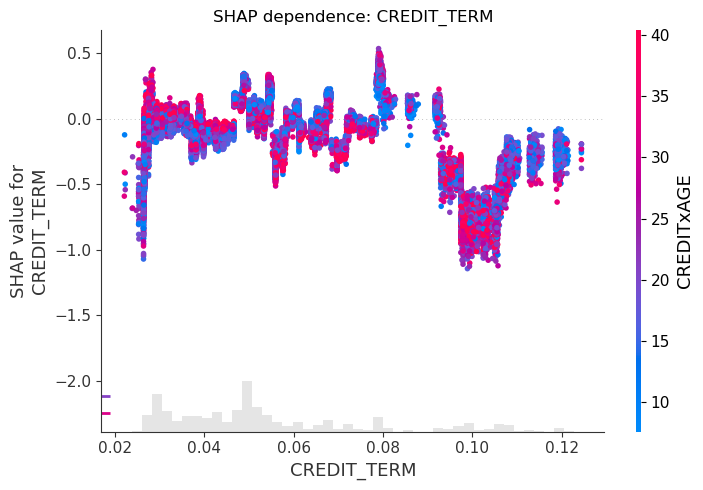

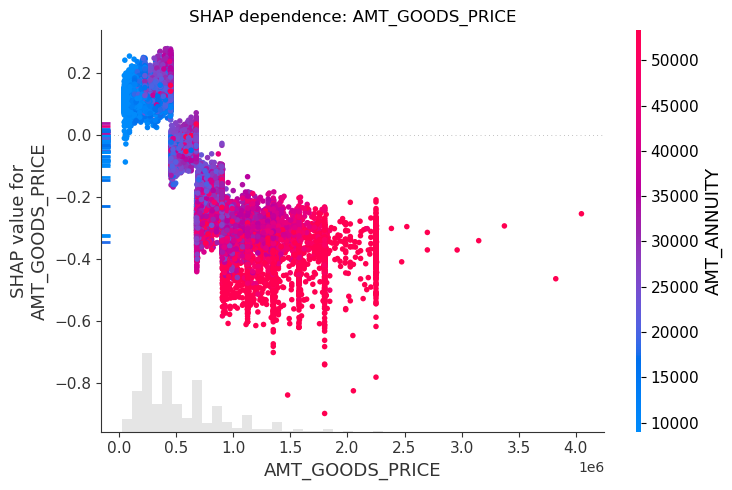

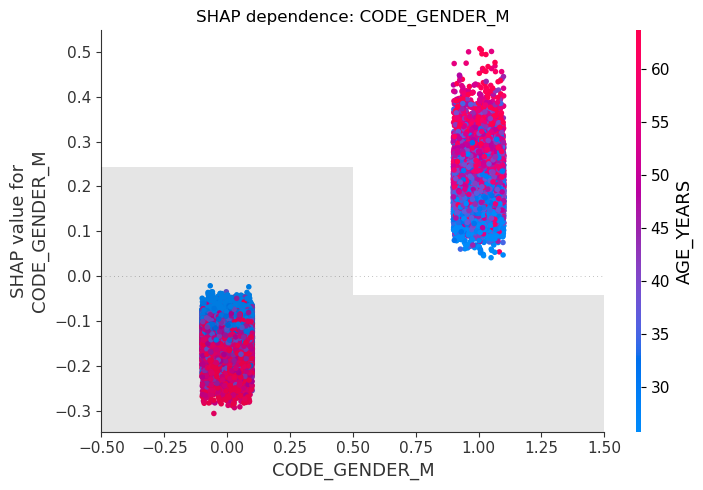

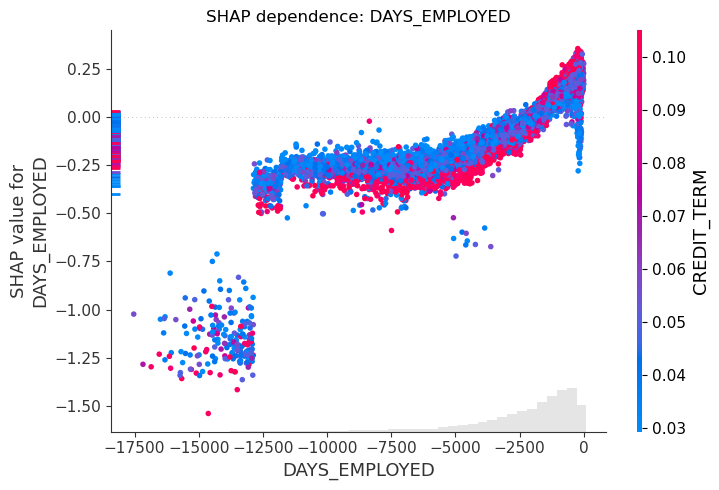

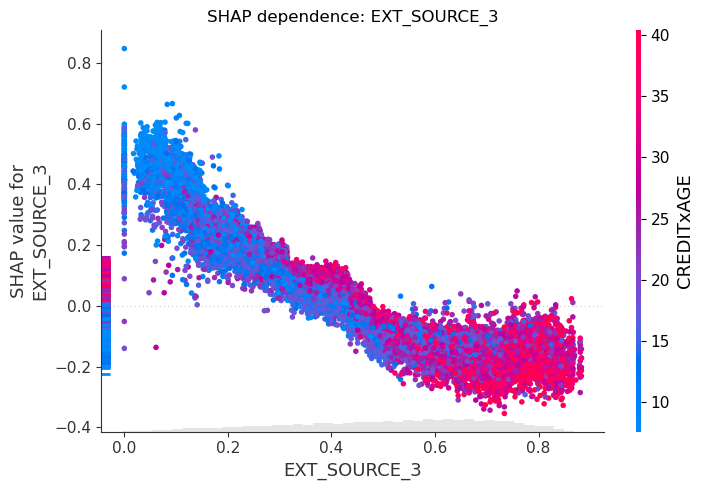

In [8]:
top6 = [c for c in top15_shap.index if not c.startswith('FLAG_')][:6]
fig_cols = 2
fig_rows = 3
for feat in top6:
    shap.plots.scatter(sv[:, feat], color=sv, show=False)
    plt.title(f'SHAP dependence: {feat}')
    plt.tight_layout()
    plt.show()

## 6. Local explanations — individual applicants

Waterfall plots decompose a single prediction: start at the base value, each bar is one feature's push. This is the "why was *this* loan flagged" view a credit officer would need (and the kind of reason-code output regulators ask for).

In [9]:
probs = model.predict_proba(X_test)[:, 1]
hi = int(np.argmax(probs))   # riskiest applicant in test set
lo = int(np.argmin(probs))   # safest applicant in test set
print(f'Highest-risk applicant: P(default) = {probs[hi]:.3f}, actual TARGET = {y_test.iloc[hi]}')
print(f'Lowest-risk applicant:  P(default) = {probs[lo]:.3f}, actual TARGET = {y_test.iloc[lo]}')

Highest-risk applicant: P(default) = 0.957, actual TARGET = 1
Lowest-risk applicant:  P(default) = 0.004, actual TARGET = 0


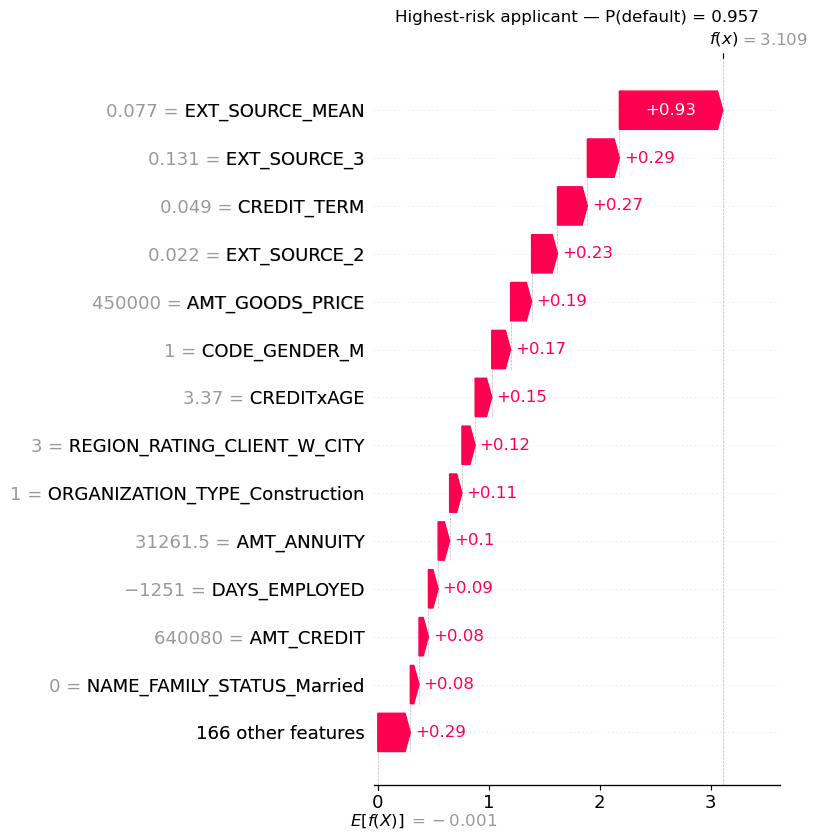

In [10]:
shap.plots.waterfall(sv[hi], max_display=14, show=False)
plt.title(f'Highest-risk applicant — P(default) = {probs[hi]:.3f}')
plt.tight_layout()
plt.show()

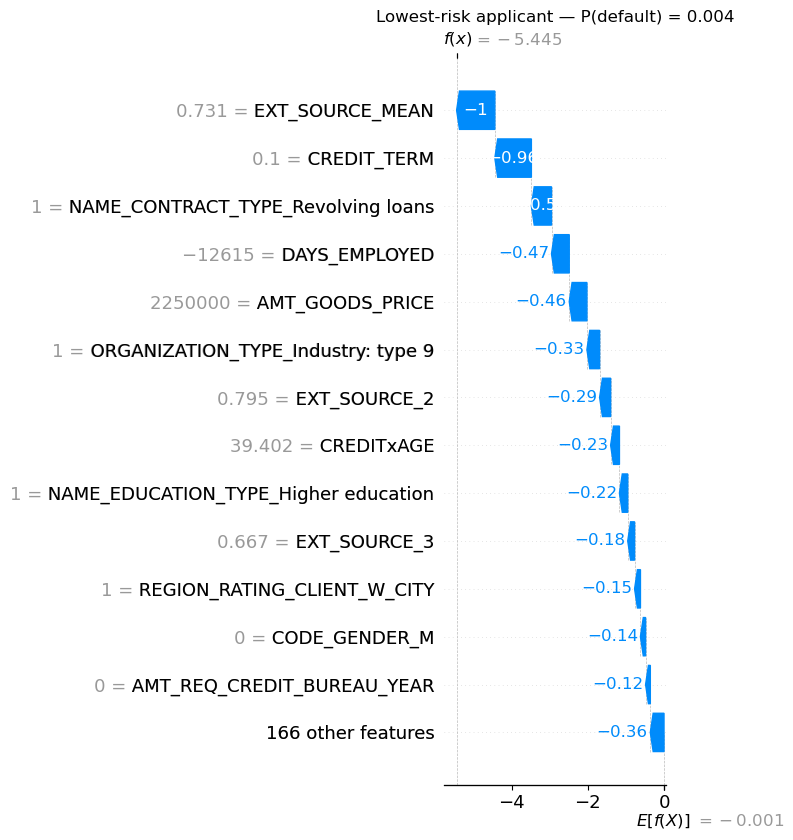

In [11]:
shap.plots.waterfall(sv[lo], max_display=14, show=False)
plt.title(f'Lowest-risk applicant — P(default) = {probs[lo]:.3f}')
plt.tight_layout()
plt.show()

### A borderline case

Applicants near the decision boundary are where explanations matter most in practice — pick the one closest to P(default) = 0.5.

Borderline applicant: P(default) = 0.500, actual TARGET = 0


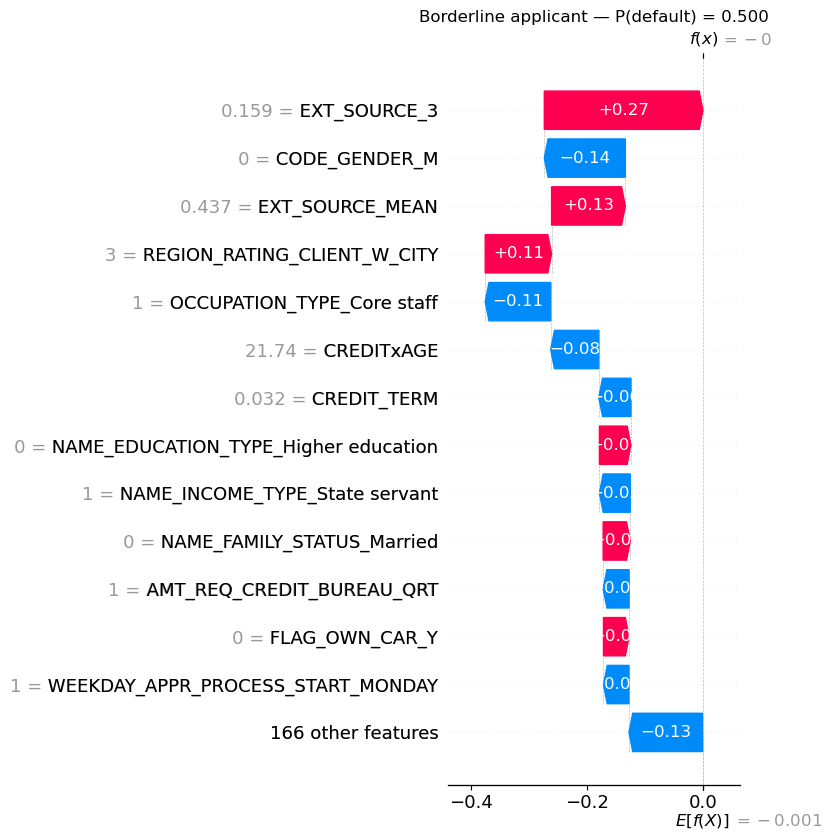

In [12]:
mid = int(np.argmin(np.abs(probs - 0.5)))
print(f'Borderline applicant: P(default) = {probs[mid]:.3f}, actual TARGET = {y_test.iloc[mid]}')
shap.plots.waterfall(sv[mid], max_display=14, show=False)
plt.title(f'Borderline applicant — P(default) = {probs[mid]:.3f}')
plt.tight_layout()
plt.show()

## 7. Findings

**1. EXT_SOURCE_MEAN dominates — by even more than gain importance suggested.**
Mean |SHAP| = 0.453 log-odds, ~2.8× the #2 feature (CREDIT_TERM, 0.163). The engineered mean matters more than either raw EXT_SOURCE column — the NaN-aware `.mean(axis=1)` decision (README Phase 3) pays off directly in the model's reasoning. Confirms SQL Finding 5 end-to-end.

**2. SHAP and gain importance disagree below rank 1 — trust SHAP.**
CREDIT_TERM is #2 by SHAP but only #11 by gain; AMT_GOODS_PRICE #3 vs #18. Conversely `NAME_EDUCATION_TYPE_Higher education` is #2 by gain but #8 by SHAP. Gain rewards features used in early high-loss splits during training; SHAP measures actual per-prediction impact on the test set. The README's Phase-4 table (based on gain) understates the repayment-burden features.

**3. Effects are non-linear (see dependence plots).**
EXT_SOURCE_MEAN's SHAP contribution swings roughly −1 to +1.5 log-odds — near-monotonic, steepest in the low-score range, i.e. the model punishes bad scores harder than it rewards great ones. DAYS_EMPLOYED shows the anomaly/NaN group handled as its own branch, matching the flag-column design.

**4. Local explanations are audit-ready.**
Highest-risk applicant (P = 0.957) — actually defaulted; low external scores plus high burden stack in the waterfall. Lowest-risk (P = 0.004) — repaid; strong scores dominate. Additivity check passed to 1e-7, so every waterfall is an exact decomposition, usable as regulator-style reason codes.

**5. Fairness flag: CODE_GENDER_M is the #4 feature by SHAP (0.154).**
Gender is a protected attribute in most credit-regulation regimes (ECOA, EU directives). Before any real-world use, retrain without it and measure the AUC cost — likely small given how dominant EXT_SOURCE is.

### Closing the loop with the SQL findings

| SQL finding | SHAP verdict |
|---|---|
| 5 — EXT_SOURCE strongest | Confirmed, #1 at ~3× runner-up |
| 1 — education beats burden | Partially — education real (#8) but burden features (CREDIT_TERM #2) outrank it once measured on predictions |
| 3 — age matters | Confirmed via CREDITxAGE (#7) and dependence-plot interaction coloring |
| 4 — family count weak | Confirmed — no family-size feature in the top 15 |
